In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as tck
from scipy.integrate import solve_bvp, simpson
import time

newparams = {'figure.figsize': (6.0, 6.0), 'axes.grid': True,
 'lines.markersize': 6, 'lines.linewidth': 2,
 'font.size': 10}
plt.rcParams.update(newparams)

## Oppgave 1

### 1a)

For å løse initialverdiproblemet
<br><br>
$$
    \frac{d^2 y}{dx^2} = -4 \sin(2x),
$$
<br><br>
med startbetingelsene:
<br><br>
$$
    y(0) = 0, \quad y'(0) = 2.
$$
<br><br>
analytisk, er det mulig å integrere to ganger over problemet for å finne løsningen
<br><br>
$$
    \frac{dy}{dx} = \int -4 \sin(2x) \, dx
$$

$$
    = -4 \cdot \left(-\frac{1}{2} \cos(2x)\right) + C_1
$$

$$
    = 2 \cos(2x) + C_1.
$$

$$
    y = \int \left(2 \cos(2x) + C_1 \right) dx
$$

$$
    = 2 \cdot \frac{1}{2} \sin(2x) + C_1 x + C_2
$$

$$
    = \sin(2x) + C_1 x + C_2.
$$
<br><br>
Deretter løser man for initialbetingelsene. Startbetingelsen gir $ y(0) = 0 $ 
<br><br>
$$
    0 = \sin(0) + C_1(0) + C_2 \quad \Rightarrow \quad C_2 = 0.
$$
<br><br>
Videre er det oppgitt at $ y'(0) = 2 $ 
<br><br>
$$
    2 = 2 \cos(0) + C_1
$$

$$
    2 = 2(1) + C_1
$$

$$
    C_1 = 0.
$$
<br><br>
Løsningen av initialverdiproblemet blir dermed
<br><br>
$$
    y(x) = \sin(2x).
$$



### 1b)

Det er ønsket å skrive om andreordens differensiallikningen fra oppgave 1a) om til en førsteordens differensialligning for vektor 

<br><br>
$$
\vec{y}(x) = \begin{pmatrix} {y}(x) \\ {y'}(x)\end{pmatrix}
$$
<br><br>

Det vil være hensiktsmessig å sette $ y(x)=y_1(x) $, og $y'(x)=y_2(x)$ for å skrive om til et førsteordens system. 
Dermed blir

<br><br>
$$
\vec{y}(x) = \begin{pmatrix} {y}(x) \\ {y'}(x)\end{pmatrix}= \begin{pmatrix} {y_1}(x) \\ {y_2}(x)\end{pmatrix}
$$
<br><br>

Det gir videre $ y_1(x)'=y'(x)=y_2(x) $ og $y_2'(x)=y''(x)=-4\sin(2x)$ som resulterer i første ordens system

<br><br>
$$
\vec{y}(x) = \begin{pmatrix} {y}(x) \\ {y'}(x)\end{pmatrix}= \begin{pmatrix} {y_1}(x) \\ {y_2}(x)\end{pmatrix}= \begin{pmatrix} {y_2}(x) \\ {-4\sin}(2x)\end{pmatrix}
$$
<br><br>

Dette kan kombineres med de kjente initialverdiene

<br><br>
$$
\vec{y}(0) = \begin{pmatrix} {y}(0) \\ {y'}(0)\end{pmatrix}=\begin{pmatrix} 0\\2\end{pmatrix}
$$
<br><br>

Som resulterer i

<br><br>
$$
\vec{y}(x) = \begin{pmatrix} {y_1'}(x)={y_2}(x) \\ {y_2'}(x)={-4\sin}(2x) \\ {y_1}(0)=0, \quad  {y_2}(0)=2 \end{pmatrix} 
$$



### 1c)

In [22]:
def f(x,y):
    return np.array([y[1], -4*np.sin(2*x)])

In [29]:
def solve_rk(f, x_init, x_end, y_init, h0, tol, alpha):
    n, m = 0, 0
    x_list = [x_init]
    y_list = [y_init]
    h_list = []

    x = x_init
    y = np.array(y_init)
    h = h0

    k1 = f(x, y)

    while x < x_end:
        n += 1
        
        if x + h > x_end:
            h = x_end - x

        k2 = f(x + h/2, y + h*k1/2)
        k3 = f(x + 3*h/4, y + 3*h*k2/4)

        y_next = y + h*(2*k1 + 3*k2 + 4*k3)/9
        k4 = f(x + h, y_next)
        
        z_next = y + h*(7*k1 + 6*k2 + 8*k3 + 3*k4)/24
        est = np.linalg.norm(y_next - z_next)

        if est < tol:
            m += 1
            x += h
            y = z_next ## y eller z?

            x_list.append(x)
            y_list.append(y)
            h_list.append(h)

            k1 = k4

        if est == 0:
            h = 2*h
        else:
            h = alpha*h*(tol/est)**(1/3)

    return np.array(x_list), np.array(y_list), np.array(h_list), n, m





Totalt antall steg: 1071
Aksepterte steg: 1070
Forkastede steg: 1


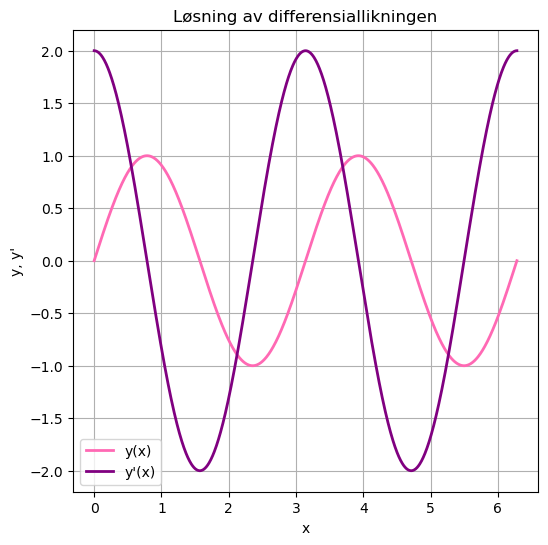

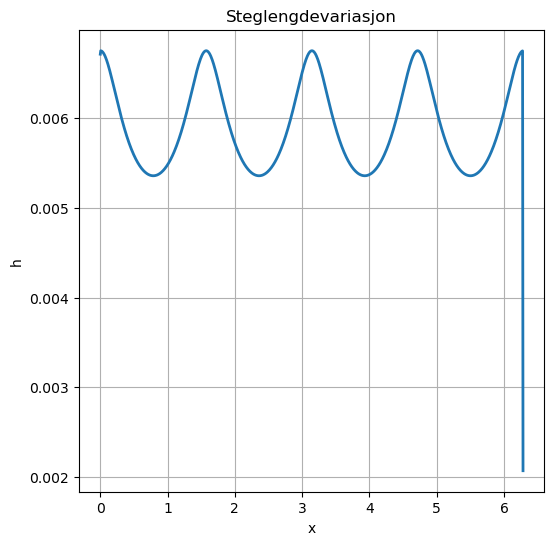

In [30]:

x_init = 0.0
x_end = 2*np.pi
h0 = 0.1
tol = 10**(-7)
alpha = 0.8
y_init = np.array([0, 2])

x_vals, y_vals, h_vals, n, m = solve_rk(f, x_init, x_end, y_init, h0, tol, alpha)

y1 = y_vals[:, 0]
y2 = y_vals[:, 1]

print("Totalt antall steg:", n)
print("Aksepterte steg:", m)
print("Forkastede steg:", n - m)

plt.figure()
plt.plot(x_vals, y1, label="y(x)", color="hotpink")
plt.plot(x_vals, y2, label="y'(x)", color="purple")
plt.xlabel("x")
plt.ylabel("y, y'")
plt.title("Løsning av differensiallikningen")
plt.legend()
plt.grid(True)
plt.show()

plt.figure()
plt.plot(x_vals[:-1], h_vals)
plt.title("Steglengdevariasjon")
plt.xlabel("x")
plt.ylabel("h")
plt.grid(True)
plt.show()

### Kommentar til kode:

Feilestimatet og oppdateringen av steglengden er gitt ved

$$
\mathrm{est}_{n+1} = \left\lVert \vec{y}_{n+1} - \vec{z}_{n+1} \right\rVert
$$

og

$$
h_{\mathrm{new}} = \alpha h_n \left(\frac{\mathrm{tol}}{\mathrm{est}}\right)^{1/3}.
$$

Figuren for løsningskomponentene viser at løsningene oppfører seg som forventet. Fra oppgave 1a vet vi at den eksakte løsningen er

$$
y(x) = \sin(2x), \qquad y'(x) = 2\cos(2x),
$$

og plottet fra koden følger denne periodiske oppførselen. Kjøringen ga 1070 aksepterte steg og 1 forkastet steg.

Plottet av steglengden viser at skrittlengden varierer periodisk med $x$. Dette skyldes at løsningen noen steder endrer seg raskere enn andre. Når løsningen varierer raskt, blir feilestimatet $\mathrm{est}_{n+1}$ større, og da må metoden redusere steglengden for å holde feilen under toleransen. Når løsningen varierer langsommere, blir feilestimatet mindre, og steglengden kan økes. Derfor blir steglengden minst der løsningen krummer mest, og størst der løsningen varierer mer rolig.


sammenlign/lag tabell med ulike alpha og tol for å se hvor mange steg man får

### 1d)

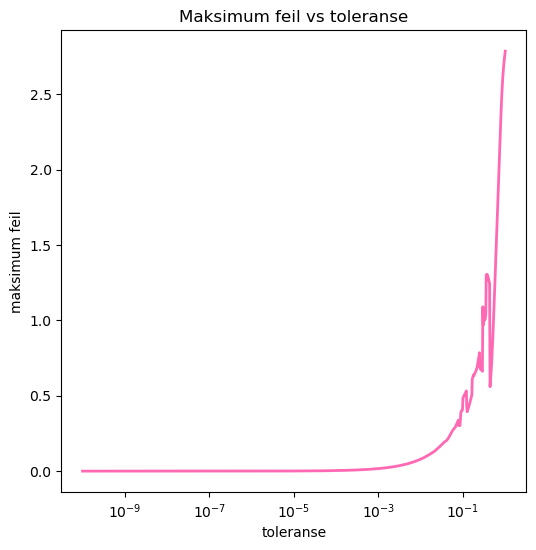

In [ ]:
num = 1000
tols = np.logspace(-10, 0, num)
x_init = 0
x_end = 2 * np.pi
y_init = np.array([0, 2])
h0 = 0.1
alpha = 0.8
tot_error = np.zeros(num)

for i, tol in enumerate(tols):
    x_vals, y_vals, h_vals, n, m = solve_rk(f, x_init, x_end, y_init, h0, tol, alpha)
    
    y1_vals = y_vals[:,0]
    tot_error[i] = np.max(np.abs(np.sin(2*x_vals) - y1_vals))

plt.plot(tols, tot_error, color = "hotpink")
plt.xlabel("toleranse")
plt.xscale("log")
plt.ylabel("maksimum feil")
plt.title("Maksimum feil vs toleranse")
plt.grid()
plt.show()

Fra plottet kan det observeres at den maksimale feilen øker med toleransen. Fra $10^{-10}$ frem til omtrent $10^{-4}$ viser plottet en lav feil som ser ut til å holde seg konstant. Dette vil si at metoden er svært nøyatig i dette ibetrvallet, og at det ikke vil være et stort behov for å redusere toleransen. 
Fra $10^{-4}$ til $10^{-2}$ øker feilen jevnt med en glatt kurve. I dette området styres feilen som forventet av toleransen, og metoden er stabil. For større toleranser observeres et avvik i plottet. Dette er ikke uventet ettersom en større toleranse vil tillate større feil per steg, og små endringer i toleranse kan dermed gi store utslag. Dette kan resultere i svinginger eller støy i plottet, og i dette området vil derfor ikke metoden fungere svært godt.


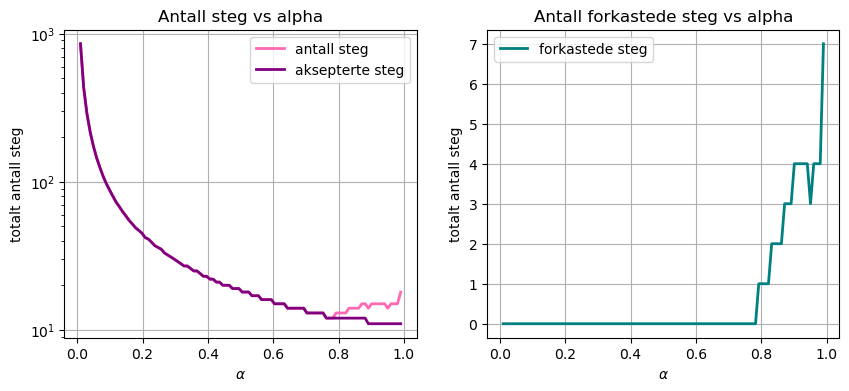

In [33]:
alpha_vals = np.linspace(0.01, 0.99, 100)
x_init = 0
x_end = 2 * np.pi
y_init = [0, 2]  
tol = 0.1
n_steps = []
a_steps = []
reject_steps = []



for alpha in alpha_vals:
    x_vals, y_vals, h_vals, num_steps, accepted_steps = solve_rk(f, x_init, x_end, y_init, h0, tol, alpha)
    n_steps.append(num_steps)
    a_steps.append(accepted_steps)
    reject_steps.append(num_steps - accepted_steps)


reject = len(n_steps) - len(a_steps)

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(alpha_vals, n_steps, color = "hotpink", label = "antall steg")
plt.plot(alpha_vals, a_steps, color = "purple", label = "aksepterte steg")
plt.xlabel(r"$\alpha$")
plt.yscale("log")
plt.ylabel("totalt antall steg")
plt.title("Antall steg vs alpha")
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(alpha_vals, reject_steps, label="forkastede steg", color = "teal")
plt.xlabel(r"$\alpha$")
plt.ylabel("totalt antall steg")
plt.title("Antall forkastede steg vs alpha")
plt.legend()
plt.grid(True)
plt.show()

Fra plottet observeres det at en økende alpha resulterer i at antall steg minker frem til $\alpha$ omtrent lik $0.8$. Dette har en sammenheng med formelen som brukes for å justere steglengden, $h_{new} = \alpha ·h·(\frac{tol}{est})^{1/3}$. Når $\alpha$ øker vil steglengden $h$ også gjøre det, og det vil dermed kreves et mindre antall steg for å nå $x_{end}$. Fra $\alpha = 0$ til  

Når $\alpha \approx 0.8$, øker antall steg for det totalte antallet steg tatt, mens de akspeterte stegene synker og flater ut. Ettersom en økende $\alpha$ gir en økning for $h$, kan dette resultere i at $est > tol$. Dermed vil flere steg måtte forkastes, og antall steg må dermed øke. Den mest optimale verdien for $\alpha$ vil altså være en $\alpha$ som er så høy som mulig uten at antall forkastede steg dominerer.

### 1e)

In [44]:
def secant(g, z0, z1, tol):
    max_iterations = 100
    z_values = [z0, z1]

    for i in range(max_iterations):
        if np.abs(z1 - z0) < tol:
            return z1, z_values

        gz0 = g(z0)
        gz1 = g(z1)

        if gz1 == gz0:
            raise ValueError("Nevneren ble null i sekantmetoden")

        z = (z0 * gz1 - z1 * gz0) / (gz1 - gz0)

        z0, z1 = z1, z
        z_values.append(z1)

    raise ValueError(f"Konvergerer ikke etter {max_iterations} iterasjoner")

In [45]:
def g_test(z):
    return z + np.sin(z) + np.cos(z)

In [46]:
rot, z_values = secant(g_test, 1, 2, 1e-7)
print(f"Rot = {rot:.6f}, g(rot) = {g_test(rot):.6e}")

Rot = -0.456625, g(rot) = 8.548717e-15


Ved bruk av sekantmetoden er det mulig å finne en tilnærmet rot til $g(z) = z + sin(z) + cos(z)$. Metoden konvergerer til $z = -0.4566 $ som resulterer i en funksjonsverdi tilmærmet nær 0. 

### 1f)

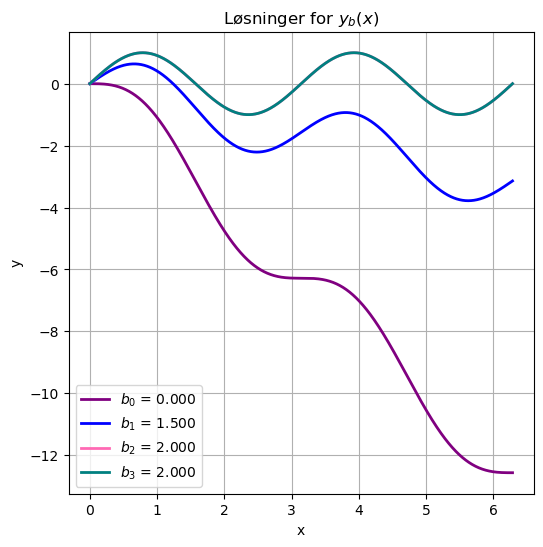

Funnet b = 1.99999459


In [47]:
def g_shoot(b):
    x_init = 0
    x_end = 2*np.pi
    y_init = [0, b]
    h0 = 1e-2
    tol_g = 1e-7
    alpha = 0.8

    x_vals, y_vals, h_vals, n, m = solve_rk(f, x_init, x_end, y_init, h0, tol_g, alpha)

    return y_vals[-1, 0]

b0 = 0.0
b1 = 1.5

b_root, b_values = secant(g_shoot, b0, b1, tol=1e-8)

x_init = 0
x_end = 2*np.pi
h0 = 1e-2
tol_g = 1e-7
alpha = 0.8

colors = ["purple", "blue", "hotpink", "teal", "orange", "green"]

plt.figure()

for i, b in enumerate(b_values):
    y_init = [0, b]
    x_vals, y_vals, h_vals, n, m = solve_rk(f, x_init, x_end, y_init, h0, tol_g, alpha)
    plt.plot(x_vals, y_vals[:, 0], label=f"$b_{i}$ = {b:.3f}", color=colors[i % len(colors)])

plt.grid(True)
plt.xlabel("x")
plt.ylabel("y")
plt.title(r"Løsninger for $y_b(x)$")
plt.legend()
plt.show()

print(f"Funnet b = {b_root:.8f}")

Ved å bruke sekantmetoden er det mulig å løse samme problem som i 1a) uten å kjenne til verdian av $y'(x_{init})$. Ved å gi to intielle gjett for b-verdiene $b_0$ og $b_1$, justerer sekantmetoden $b$ for å tilfredstille randbetingelsene. Etter få iterasjoner er verdien av $b$ lik, altså konvergerer kurvene mot en løsning. De to siste kruvene er nesten identiske med et lite avvik av størrelsesorden $10^{-10}$ som vises i plottet under. 

noe om skytemetoden???

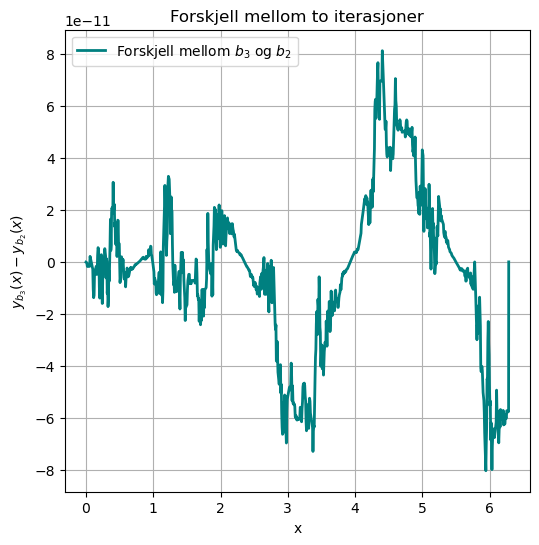

In [54]:
y_init_b3 = [0, b_values[3]]
y_init_b2 = [0, b_values[2]]

x_vals, y_b3, h, n, m = solve_rk(f, x_init, x_end, y_init_b3, h0, tol_g, alpha)
x_vals, y_b2, h, n, m = solve_rk(f, x_init, x_end, y_init_b2, h0, tol_g, alpha)

diff = y_b3[:, 0] - y_b2[:, 0]

plt.figure()
plt.plot(x_vals, diff, label=r"Forskjell mellom $b_3$ og $b_2$", color="teal")
plt.grid(True)
plt.xlabel("x")
plt.ylabel(r"$y_{b_3}(x) - y_{b_2}(x)$")
plt.title("Forskjell mellom to iterasjoner")
plt.legend()
plt.show()

### 1g)

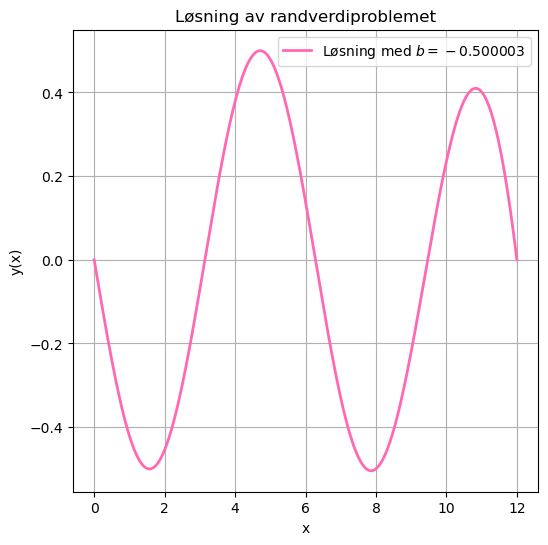

Funnet b = -0.50000323
Kjøretid = 1.556012 s
y(12) = 3.928e-11


In [ ]:

def f_1g(x, y):
    return np.array([y[1], y[0] + np.sin(x)])

def g_shoot_1g(b):
    x_init = 0
    x_end = 12
    y_init = np.array([0.0, b])
    h0 = 0.1
    tol = 1e-7
    alpha = 0.8

    x_vals, y_vals, h_vals, n, m = solve_rk(f_1g, x_init, x_end, y_init, h0, tol, alpha)
    return y_vals[-1, 0]   #ønsker y(12)=0

x_init = 0
x_end = 12
h0 = 0.1
tol = 1e-7
alpha = 0.8

b0 = 0.0
b1 = 1.0

start_num = time.perf_counter()

b_root, b_values = secant(g_shoot_1g, b0, b1, tol)

y_init = np.array([0.0, b_root])
x_vals, y_vals, h_vals, n, m = solve_rk(f_1g, x_init, x_end, y_init, h0, tol, alpha)

end_num = time.perf_counter()

plt.figure()
plt.plot(x_vals, y_vals[:, 0], label=fr"Løsning med $b={b_root:.6f}$", color="hotpink")
plt.title("Løsning av randverdiproblemet")
plt.xlabel("x")
plt.ylabel("y(x)")
plt.grid(True)
plt.legend()
plt.show()

print(f"Funnet b = {b_root:.8f}")
print(f"Kjøretid = {end_num - start_num:.6f} s")
print(f"y(12) = {y_vals[-1,0]:.3e}")

Randverdiproblemet ble løst ved skytemetoden kombinert med sekantmetoden. Den optimale initialverdien ble funnet til $b \approx -0.50000323$. Den numeriske løsningen tilfredsstiller randbetingelsen godt, siden $y(12) \approx 3.93 \cdot 10^{-11} \approx 0$. Dette viser at metoden gir en svært presis tilnærming til den eksakte løsningen.

### 1h)

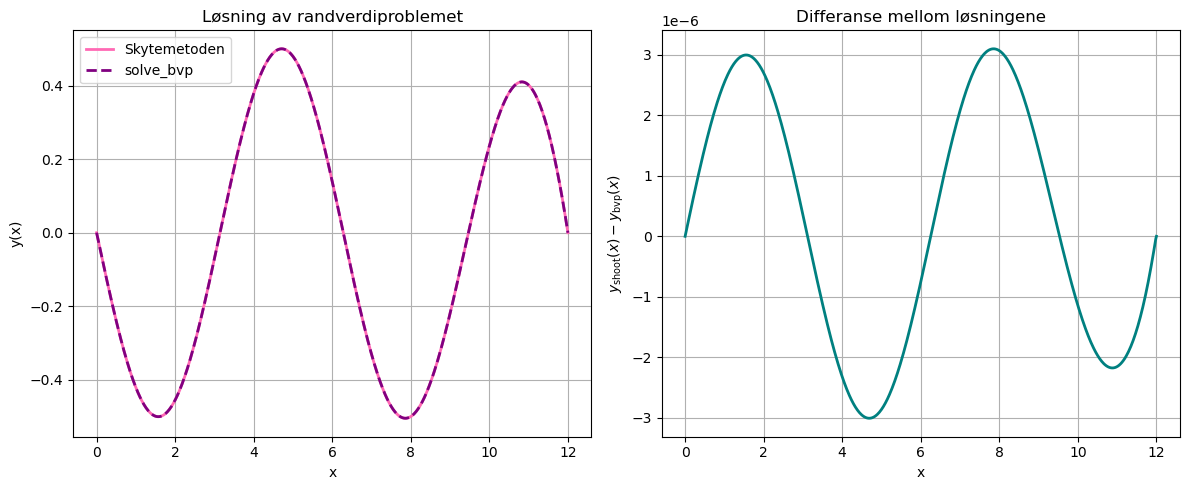

Tid skytemetoden: 1.341033 s
Tid solve_bvp: 0.004511 s
Maks absolutt differanse: 3.100e-06


In [58]:
def fun(x, y):
    return np.vstack((y[1], y[0] + np.sin(x)))

def bc(ya, yb):
    return np.array([ya[0], yb[0]])

#Skytemetoden fra 1g
start_shoot = time.perf_counter()
b_root, b_values = secant(g_shoot_1g, 0.0, 1.0, 1e-7)
y_init = np.array([0.0, b_root])
x_vals, y_vals, h_vals, n, m = solve_rk(f_1g, 0, 12, y_init, 0.1, 1e-7, 0.8)
end_shoot = time.perf_counter()

#solve_bvp
start_scipy = time.perf_counter()
x_bvp = np.copy(x_vals)
y_guess = np.zeros((2, x_bvp.size))
res = solve_bvp(fun, bc, x_bvp, y_guess)
end_scipy = time.perf_counter()

#Differanse
diff = y_vals[:, 0] - res.sol(x_vals)[0]

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(x_vals, y_vals[:, 0], label="Skytemetoden", color="hotpink")
plt.plot(res.x, res.y[0], "--", label="solve_bvp", color="purple")
plt.xlabel("x")
plt.ylabel("y(x)")
plt.title("Løsning av randverdiproblemet")
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(x_vals, diff, color="teal")
plt.xlabel("x")
plt.ylabel(r"$y_{\mathrm{shoot}}(x)-y_{\mathrm{bvp}}(x)$")
plt.title("Differanse mellom løsningene")
plt.grid(True)

plt.tight_layout()
plt.show()

print(f"Tid skytemetoden: {end_shoot - start_shoot:.6f} s")
print(f"Tid solve_bvp: {end_scipy - start_scipy:.6f} s")
print(f"Maks absolutt differanse: {np.max(np.abs(diff)):.3e}")

Det første plottet viser løsningen av randverdiproblemet funnet med solve_bvp sammenlignet med løsningen fra skytemetoden. Kurvene ligger oppå hverandre gjennom hele intervallet, noe som viser at metodene gir svært god overensstemmelse. Løsningen er glatt og oscillerende, slik man forventer siden differensiallikningen inneholder leddet $\sin(x)$.

Det andre plottet viser differansen mellom løsningen fra skytemetoden og løsningen fra solve_bvp. Differansen er svært liten over hele intervallet, med maksimal absolutt differanse lik omtrent $3.1 \cdot 10^{-6}$. Dette tyder på at begge metodene gir en numerisk svært presis tilnærming til samme løsning. At differansen varierer svakt og har en bølgeformet struktur kan forklares ved at den numeriske feilen følger den oscillerende formen til selve løsningen.

Når det gjelder kjøretid, er solve_bvp klart raskere enn skytemetoden for dette problemet. Skytemetoden brukte omtrent $1.34\,\text{s}$, mens solve_bvp brukte omtrent $0.0045\,\text{s}$. Siden solve_bvp både er raskere og gir en løsning som stemmer svært godt overens med skytemetoden, foretrekkes solve_bvp her.

## Oppgave 2

### 2a)

In [70]:
def matrixToVector(M):
    M = np.array(M)
    return np.concatenate([M.real.flatten(), M.imag.flatten()])


In [71]:
def vectorToMatrix(m):
    real_part = m[:4].reshape(2, 2)
    imag_part = m[4:].reshape(2, 2)
    return real_part + 1j * imag_part

In [ ]:
M = np.array([[1+2j, 3+4j],
              [5+6j, 7+8j]])

m = matrixToVector(M)
M_reconstructed = vectorToMatrix(m)

print("Vektor:", m)                          
print("Rekonstruert matrise:\n", M_reconstructed)
print("Inverse korrekt:", np.allclose(M, M_reconstructed)) 

Vektor: [1. 3. 5. 7. 2. 4. 6. 8.]
Rekonstruert matrise:
 [[1.+2.j 3.+4.j]
 [5.+6.j 7.+8.j]]
Inverse korrekt: True


### 2b)

In [72]:
def addVectors(m1, m2, m3, m4): #for arrays m1, m2, m3, m4
    v = np.concatenate((m1, m2, m3, m4))
    return v

def splitVectors(v): #for array v
    m1 = v[0:8]
    m2 = v[8:16]
    m3 = v[16:24]
    m4 = v[24:32]
    return m1, m2, m3, m4

In [74]:
m1, m2, m3, m4 = [1,2,3,4,5,6,7,8],[9,0,1,2,3,4,5,6],[7,8,9,0,1,2,3,4],[5,6,7,8,9,0,1,2]
v = [1,2,3,4,5,6,7,8,9,0,1,2,3,4,5,6,7,8,9,0,1,2,3,4,5,6,7,8,9,0,1,2]
print(addVectors(m1, m2, m3, m4))
print(splitVectors(v))

m1_r, m2_r, m3_r, m4_r = splitVectors(addVectors(m1, m2, m3, m4))
print("Round-trip test:", np.allclose(m1, m1_r) and np.allclose(m2, m2_r) and
      np.allclose(m3, m3_r) and np.allclose(m4, m4_r))

[1 2 3 4 5 6 7 8 9 0 1 2 3 4 5 6 7 8 9 0 1 2 3 4 5 6 7 8 9 0 1 2]
([1, 2, 3, 4, 5, 6, 7, 8], [9, 0, 1, 2, 3, 4, 5, 6], [7, 8, 9, 0, 1, 2, 3, 4], [5, 6, 7, 8, 9, 0, 1, 2])
Round-trip test: True


Her er det brukt fire vektorer m1–m4 og en vektor v sammensatt av disse til å sjekke om funksjonene klarer å sette sammen vektorer (arrays) og separere dem. I tillegg kjøres en round-trip-test med np.allclose for å bekrefte at funksjonene er inverse av hverandre.

### 2c)

In [80]:
def addMatrices(g,gt,w,wt): #for arrays gamma, gamma tilde,o mega, omega tilde
    v = addVectors(matrixToVector(g), matrixToVector(gt), matrixToVector(w), matrixToVector(wt))
    return v

def splitMatrices(v): # for array v
    vec_g, vec_gt, vec_w, vec_wt = splitVectors(v)
    g, gt, w, wt = vectorToMatrix(vec_g), vectorToMatrix(vec_gt), vectorToMatrix(vec_w), vectorToMatrix(vec_wt)
    return g, gt, w, wt

g = np.array([[1+2j, 3+4j],[5+6j, 7+8j]])
gt = np.array([[1+1j, 2+2j],[3+3j, 4+4j]])
w = np.array([[0+1j, 1+0j],[1+1j, 0+0j]])
wt = np.array([[2+1j, 0+2j],[1+0j, 2+1j]])

v = addMatrices(g, gt, w, wt)
print("Alle 32 komponenter i v:")
print("v[0:8]   (gamma) :", v[0:8])
print("v[8:16]  (gamma~) :", v[8:16])
print("v[16:24] (omega) :", v[16:24])
print("v[24:32] (omega~) :", v[24:32])

Alle 32 komponenter i v:
v[0:8]   (gamma) : [1. 3. 5. 7. 2. 4. 6. 8.]
v[8:16]  (gamma~) : [1. 2. 3. 4. 1. 2. 3. 4.]
v[16:24] (omega) : [0. 1. 1. 0. 1. 0. 1. 0.]
v[24:32] (omega~) : [2. 0. 1. 2. 1. 2. 0. 1.]


Vektoren **v** har 32 komponenter fordelt på fire 8-komponent blokker, 
én per matrise (γ, γ̃, ω, ω̃). Hver blokk inneholder realdelen av alle 
fire elementer etterfulgt av imaginærdelen, som vist i utskriften over.

### 2d)

In [87]:
delta = 0.01
I = np.identity(2)
zeta = 3
l = 1
m = 101

def derivative(v, eps):
    g, gt, w, wt = splitMatrices(v) # gamma, gamma tilde, omega, omega tilde
    
    N = np.linalg.inv(I - g @ gt)
    Nt = np.linalg.inv(I - gt @ g)

    dx_g, dx_gt = w, wt
    dx_w = -2j * (eps + 1j*delta) * g - 2 * w @ Nt @ gt @ w
    dx_wt = -2j * (eps + 1j*delta) * gt - 2 * wt @ N @ g @ wt
    return addMatrices(dx_g, dx_gt, dx_w, dx_wt) 


np.set_printoptions(linewidth=120)
v_test = addMatrices(g, gt, w, wt)
dv = derivative(v_test, eps=1.0)
print("∂xv (gamma) :", dv[0:8])
print("∂xv (gamma~):", dv[8:16])
print("∂xv (omega) :", dv[16:24])
print("∂xv (omega~):", dv[24:32])

∂xv (gamma) : [0. 1. 1. 0. 1. 0. 1. 0.]
∂xv (gamma~): [2. 0. 1. 2. 1. 2. 0. 1.]
∂xv (omega) : [  4.68415094   7.32037736  11.90377358  15.65698113  -2.15622642  -6.25207547 -10.39320755 -12.94943396]
∂xv (omega~): [ 2.51056604 -1.2354717   9.53169811 10.1554717   4.69924528 -2.61660377 -6.61924528 -5.08981132]


Funksjonen tar vektoren v og energien ε som input, og returnerer 
den deriverte ∂x**v** som en 32-komponent vektor. Dette er Usadel-ligningene 
(9)-(12) for én energi og én posisjon.

### 2e)

In [92]:
def make_fun(eps):
    def fun(x, vec):
        dx_vec = np.zeros_like(vec)
        for i in range(len(x)):
            dx_vec[:, i] = derivative(vec[:, i], eps)
        return dx_vec
    return fun

#Tester at output har riktig format for solve_bvp
eps_test = 1.0
fun_test = make_fun(eps_test)
x_test = np.linspace(0, l, m)
vec_test = np.zeros((32, m))

result = fun_test(x_test, vec_test)
print("Output shape:", result.shape)  #skal være (32, 101)

Output shape: (32, 101)


Funksjonen make_fun(eps) returnerer en funksjon fun(x, vec) som beregner 
∂x**v** i alle *m* posisjoner. Wrapper-strukturen er nødvendig fordi solve_bvp 
krever at $fun$ kun tar to argumenter $(x, vec)$. Output-shape $(32, 101)$ 
bekrefter at formatet er korrekt for solve_bvp.

### 2f)

In [ ]:
def bc(vL, vR):
    gL, gtL, wL, wtL = splitMatrices(vL)
    gR, gtR, wR, wtR = splitMatrices(vR)

    gBL = gtBL = gBR = gtBR = np.zeros((2,2), dtype=complex)

    NL  = np.linalg.inv(I - gBL @ gtBL)
    NtL = np.linalg.inv(I - gtBL @ gBL)
    NR  = np.linalg.inv(I - gBR @ gtBR)
    NtR = np.linalg.inv(I - gtBR @ gBR)

    v1 = wL + 1/(zeta*l) * (I - gL @ gtBL) @ NL  @ (gBL - gL)
    v2 = wtL + 1/(zeta*l) * (I - gtL @ gBL) @ NtL @ (gtBL - gtL)
    v3 = wR - 1/(zeta*l) * (I - gR @ gtBR) @ NR  @ (gBR - gR)
    v4 = wtR - 1/(zeta*l) * (I - gtR @ gBR) @ NtR @ (gtBR - gtR)

    return addMatrices(v1, v2, v3, v4)

vL = np.zeros(32)
vR = np.zeros(32)
result = bc(vL, vR)
print("bc output shape:", result.shape)  #(32,)
print("bc output:", result)              #skal være bare 0-er siden alt er null

bc output shape: (32,)
bc output: [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]


Funksjonen bc beregner venstresidene av grensebetingelsene 13-16 
og returnerer disse som én 32-komponent vektor. Siden alle Riccati-matrisene 
er null (normal metall), gir testen en nullvektor, som forventet.

### 2g)

In [97]:
x = np.linspace(0, l, m)
y = np.zeros((32, m))
eps_lst = [0, 1, 2]
solutions = {}

for eps in eps_lst:
    res = solve_bvp(make_fun(eps), bc, x, y)
    solutions[eps] = res.y
    print(f"eps={eps}, converged: {res.success}, max|v|: {np.max(np.abs(res.y)):.2e}")

eps=0, converged: True, max|v|: 0.00e+00
eps=1, converged: True, max|v|: 0.00e+00
eps=2, converged: True, max|v|: 0.00e+00


Vi forventer en triviell løsning ($v = 0$ overalt) siden grensebetingelsene 
tilsvarer normale metaller med nullmatriser. res.success=True og 
max|v| ≈ 0 bekrefter at løseren konvergerer til den forventede løsningen.

### 2h)

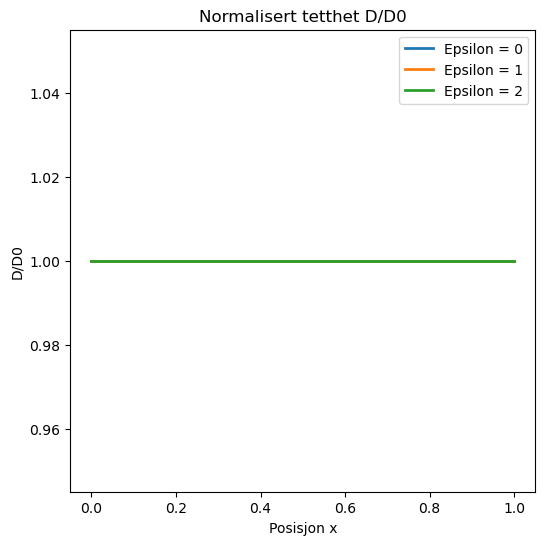

In [98]:
rhoh3 = np.block([ [I, np.zeros_like(I)],
                  [np.zeros_like(I), -I]] ) 

def gh(g, gt): #g og gt kommer fra splitMatrices(v), der v er løsningen fra solve_bvp
    N = np.linalg.inv(I - g @ gt)
    Nt = np.linalg.inv(I - gt @ g)
    return np.block([[2 * N - I, 2 * N @ g], 
                    [-2 * Nt @ gt, -2 * Nt + I]]) 

def compute_density(solutions, eps_lst):
    density_dict = {}

    for eps in eps_lst:
        density_lst = []
        for i in range(m):
            v = solutions[eps][:, i]
            g, gt, w, wt = splitMatrices(v)
            density = np.real(np.trace(rhoh3 @ gh(g, gt))) / 4
            density_lst.append(density)

        density_dict[eps] = np.array(density_lst)

    return density_dict

plt.figure()
density_data = compute_density(solutions, eps_lst)
for eps in eps_lst:
    plt.plot(x, density_data[eps],label = f"Epsilon = {eps}")

plt.title("Normalisert tetthet D/D0")
plt.legend()
plt.xlabel("Posisjon x")
plt.ylabel("D/D0")
plt.grid()
plt.show()

Tettheten $D/D0$ beregnes fra grønnfunksjonen ĝ via ligning (19). Siden 
grensebetingelsene tilsvarer normale metaller med nullmatriser (2f og 2g), forventer 
vi $D/D0 = 1$ overalt for alle energier og posisjoner. Dette er tetthetene til 
et normalt metall uten supraledere. Plottet bekrefter det, og stemmer med 
forventningene siden det ikke er noen proximity-effekt som påvirker tettheten.

### 2i)